In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Ejercicio 1:
Escribe un código que haga los siguientes cambios en la imagen dada:


Imagen original:

![Original](./Resources/Exercise/Lenna_(test_image).png "Original")


Cambio 1:

![Original](./Resources/Exercise/result_regions.png "Original")


Cambio 2:

![Original](./Resources/Exercise/result_swap.png "Original")


pista: comando np.roll

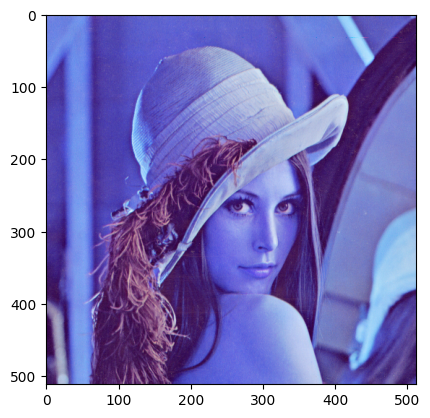

In [2]:
img = cv.imread('./Resources/Exercise/Lenna_(test_image).png')
plt.imshow(img);

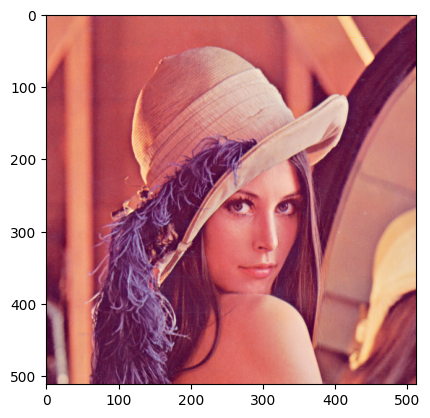

In [3]:
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB));

In [4]:
h, w = img.shape[:2]
print("Ancho:", w)
print("Alto:", h)

Ancho: 512
Alto: 512


Cambio 1:

In [5]:
blank = np.zeros(img.shape[:2], dtype='uint8')

rectangle = cv.rectangle(blank.copy(), (220,90), (500,300), 255, -1)

weird_shape = cv.bitwise_not(img, mask=rectangle)

masked = cv.bitwise_and(img,img,mask=cv.bitwise_not(rectangle))

final = cv.add(masked, weird_shape)

cv.imshow("Final result", final)

cv.waitKey(0)
cv.destroyAllWindows()

Cambio 2:

In [6]:
rolled = np.roll(img, shift=(250, 250), axis=(0, 1))

cv.imshow("Original", img)
cv.imshow("Rolled", rolled)

cv.waitKey(0)
cv.destroyAllWindows()

Ejercicio 2: Graba un video de unos segundos de tu cara moviéndose por la pantalla (que no se quede fija en el centro solamente) con tu webcam del ordenador. Haz un detector de caras con dicho vídeo. Asegúrate de que tu cara está correctamente iluminada, ya que el modelo es bastante sensible.

Extra: intenta hacerlo con vídeo en directo tomado desde tu webcam.

In [13]:
capture = cv.VideoCapture('./Resources/Videos/asier.mp4') # creamos el capturador de frames
haar_cascade = cv.CascadeClassifier('./Resources/Exercise/haarcascade_frontalface_default.xml')


while True:
    isTrue, frame = capture.read() 
    
    if not isTrue:
        break
                    
    else:
        last_frame = frame.copy()
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

        faces_rect = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5) # Nos devolverá una lista con las coordenadas 
        # rectangulares de cada una de las caras que ha identificado.

        for (x,y,w,h) in faces_rect:
            cv.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), thickness=2) # dibuja el rectángulo en las coordenadas especificadas

        cv.imshow('Detected Faces', frame)

        if cv.waitKey(20) & 0xFF==ord('c'): # permite salir del bucle pulsando la tecla 'c'
            break
capture.release()
cv.destroyAllWindows()
print(f'Number of faces found = {len(faces_rect)}')

Number of faces found = 1


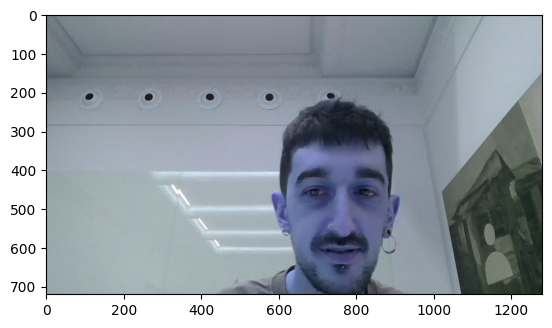

In [12]:
plt.imshow(last_frame)

Ejercicio Extra (para los que hayan terminado lo anterior)

Había una vez, un caracol con el que se metían mucho. Tanto era así, que decidió apuntarse a un gimnasio para ponerse súper fuerte para darle una paliza a todo el mundo. Sin embargo, no era capaz de apuntarse. Vuestra tarea será conseguir que el caracol se haga un selfie mientras está entrenando y le ponga un hashtag a la foto del siguiente modo:

![Original](./Resources/Exercise/gym_snail.png "selfie")

In [28]:
gym = cv.imread('./Resources/Exercise/gym.jpg')
snail = cv.imread('./Resources/Exercise/snail.jpg')

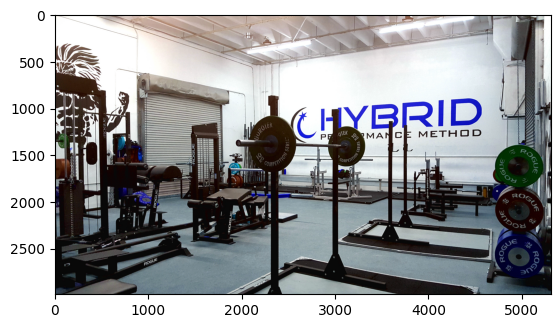

In [29]:
plt.imshow(gym)

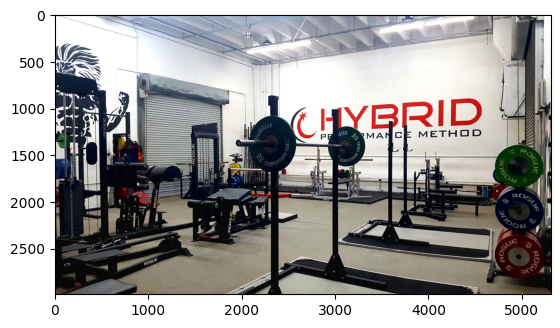

In [30]:
plt.imshow(cv.cvtColor(gym, cv.COLOR_BGR2RGB));

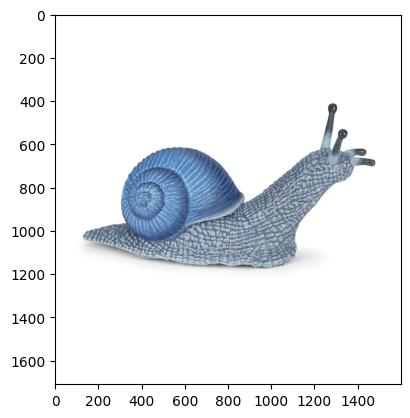

In [31]:
plt.imshow(snail)

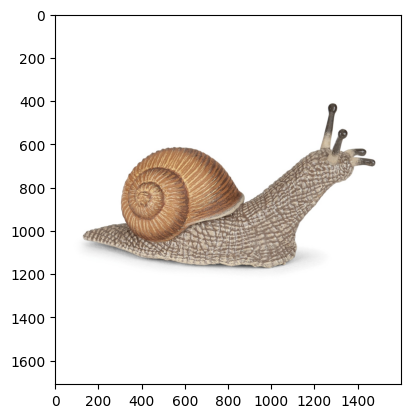

In [32]:
plt.imshow(cv.cvtColor(snail, cv.COLOR_BGR2RGB));